# Progetto Q - Analisi statistiche giocatori NBA

In questo notebook analizziamo il dataset `players_stats.csv` con l'obiettivo di
selezionare una coppia di variabili significative e costruire un modello di regressione
lineare e uno non lineare.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error
 

## Caricamento del dataset

Carico il file e controllo che i dati siano stati letti correttamente.

In [3]:
df = pd.read_csv("players_stats.csv")
df.head()

,Name,Games Played,MIN,PTS,FGM,FGA,FG%,3PM,3PA,3P%,...,Age,Birth_Place,Birthdate,Collage,Experience,Height,Pos,Team,Weight,BMI
0,AJ Price,26,324,133,51,137,37.2,15,57,26.3,...,29.0,us,"October 7, 1986",University of Connecticut,5,185.0,PG,PHO,81.45,23.798393
1,Aaron Brooks,82,1885,954,344,817,42.1,121,313,38.7,...,30.0,us,"January 14, 1985",University of Oregon,6,180.0,PG,CHI,72.45,22.361111
2,Aaron Gordon,47,797,243,93,208,44.7,13,48,27.1,...,20.0,us,"September 16, 1995",University of Arizona,R,202.5,PF,ORL,99.00,24.142661
3,Adreian Payne,32,740,213,91,220,41.4,1,9,11.1,...,24.0,us,"February 19, 1991",Michigan State University,R,205.0,PF,ATL,106.65,25.377751
4,Al Horford,76,2318,1156,519,965,53.8,11,36,30.6,...,29.0,do,"June 3, 1986",University of Florida,7,205.0,C,ATL,110.25,26.234384


## Colonne disponibili

Verifico i nomi delle colonne per individuare le variabili numeriche su cui lavorare.

In [4]:
print(df.columns.tolist())


['Name', 'Games Played', 'MIN', 'PTS', 'FGM', 'FGA', 'FG%', '3PM', '3PA', '3P%', 'FTM', 'FTA', 'FT%', 'OREB', 'DREB', 'REB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'EFF', 'AST/TOV', 'STL/TOV', 'Age', 'Birth_Place', 'Birthdate', 'Collage', 'Experience', 'Height', 'Pos', 'Team', 'Weight', 'BMI']


## Matrice di correlazione

Calcolo la matrice di correlazione tra tutte le variabili numeriche per individuare le relazioni più forti.

In [5]:
corr_matrix = df.select_dtypes(include=[np.number]).corr()
corr_matrix

,Games Played,MIN,PTS,FGM,FGA,FG%,3PM,3PA,3P%,FTM,...,BLK,TOV,PF,EFF,AST/TOV,STL/TOV,Age,Height,Weight,BMI
Games Played,1.000000,0.872959,0.727973,0.739667,0.741407,0.369492,0.492036,0.510728,0.218361,0.575342,...,0.459709,0.693894,0.860430,0.757467,0.169564,0.012988,0.139838,0.068284,0.080360,0.065185
MIN,0.872959,1.000000,0.920196,0.924123,0.926747,0.304910,0.601725,0.618675,0.278590,0.775022,...,0.499512,0.858630,0.872932,0.923723,0.198229,-0.045213,0.087547,0.009521,0.033385,0.052763
PTS,0.727973,0.920196,1.000000,0.990487,0.988716,0.275514,0.615766,0.627413,0.290644,0.909402,...,0.445102,0.883540,0.753363,0.941961,0.166571,-0.102540,0.063428,-0.016891,0.030831,0.078018
FGM,0.739667,0.924123,0.990487,1.000000,0.986789,0.310255,0.548751,0.560697,0.254783,0.868013,...,0.488795,0.872757,0.775502,0.951369,0.147698,-0.111683,0.065786,0.026565,0.077724,0.105658
FGA,0.741407,0.926747,0.988716,0.986789,1.000000,0.231871,0.624375,0.646638,0.309729,0.865389,...,0.406254,0.886276,0.757420,0.915277,0.195855,-0.100390,0.061307,-0.047915,0.002796,0.067171
FG%,0.369492,0.304910,0.275514,0.310255,0.231871,1.000000,-0.045385,-0.070072,-0.097218,0.235433,...,0.419133,0.226864,0.375768,0.383651,-0.124186,-0.064153,0.089074,0.366599,0.383616,0.216849
3PM,0.492036,0.601725,0.615766,0.548751,0.624375,-0.045385,1.000000,0.988563,0.537028,0.443760,...,-0.058761,0.495797,0.389995,0.453904,0.289378,0.065442,0.074057,-0.301668,-0.304422,-0.153515
3PA,0.510728,0.618675,0.627413,0.560697,0.646638,-0.070072,0.988563,1.000000,0.531573,0.462710,...,-0.065263,0.526029,0.407298,0.457740,0.308285,0.068205,0.060393,-0.324040,-0.326490,-0.164209
3P%,0.218361,0.278590,0.290644,0.254783,0.309729,-0.097218,0.537028,0.531573,1.000000,0.189836,...,-0.196782,0.221739,0.099524,0.160524,0.349797,0.101430,0.013422,-0.355749,-0.425045,-0.306359
FTM,0.575342,0.775022,0.909402,0.868013,0.865389,0.235433,0.443760,0.462710,0.189836,1.000000,...,0.415265,0.836937,0.623557,0.859884,0.112697,-0.126039,0.028665,-0.007247,0.040284,0.082334


## Heatmap delle correlazioni

Per avere una visione globale delle relazioni tra le variabili numeriche, rappresento la matrice di correlazione con una heatmap.


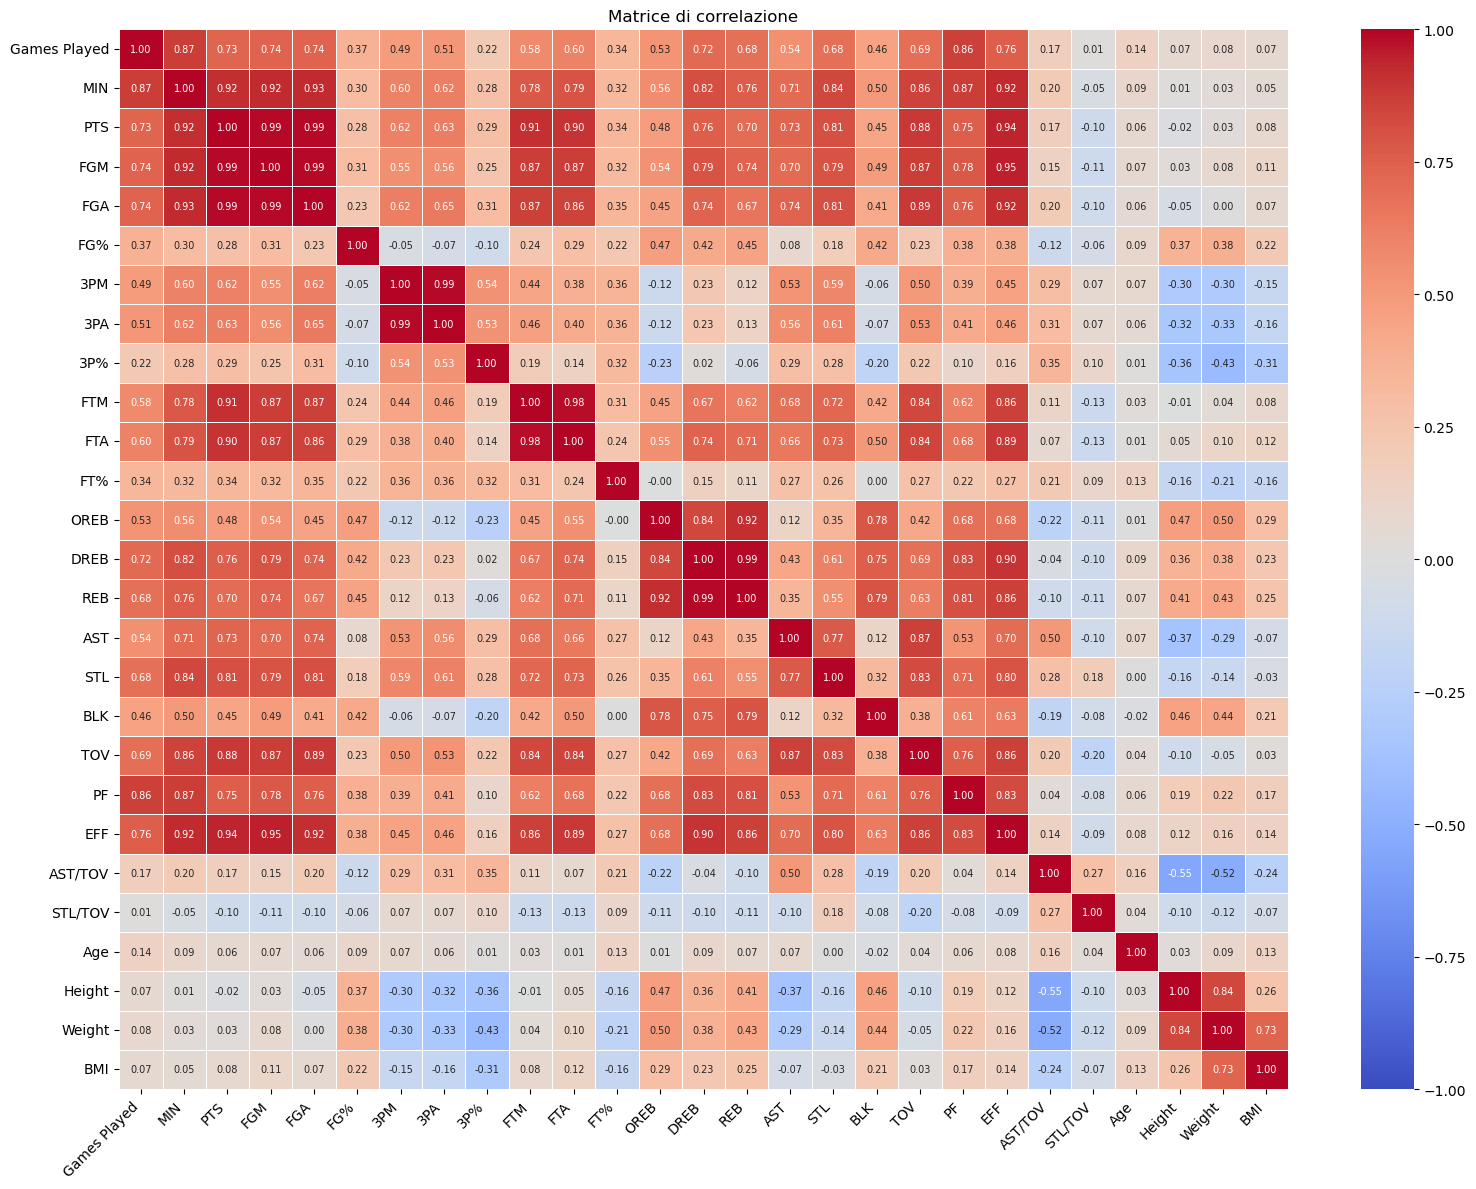

In [6]:
plt.figure(figsize=(16, 12))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    vmin=-1,
    vmax=1,
    annot_kws={"size": 7}
)

plt.title("Matrice di correlazione")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Analisi delle correlazioni

Calcolo la matrice di correlazione tra le feature numeriche per individuare coppie di variabili fortemente correlate.

In [7]:
corr_abs = corr_matrix.abs()

pairs=[]
cols=corr_abs.columns
for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        var1=cols[i]
        var2=cols[j]
        corr_value=corr_abs.loc[var1,var2]
        pairs.append((var1,var2,corr_value))
pairs_df=pd.DataFrame(pairs,columns=['Variable 1','Variable 2','Correlation'])
pairs_df_sorted=pairs_df.sort_values(by='Correlation',ascending=False).dropna()
print(pairs_df_sorted.head(15).to_string(index=False))

Variable 1 Variable 2  Correlation
       PTS        FGM     0.990487
       PTS        FGA     0.988716
       3PM        3PA     0.988563
       FGM        FGA     0.986789
      DREB        REB     0.985036
       FTM        FTA     0.981130
       FGM        EFF     0.951369
       PTS        EFF     0.941961
       MIN        FGA     0.926747
       MIN        FGM     0.924123
       MIN        EFF     0.923723
      OREB        REB     0.921286
       MIN        PTS     0.920196
       FGA        EFF     0.915277
       PTS        FTM     0.909402


## Analisi delle correlazioni principali

La tabella soprastante mostra le 15 coppie di variabili con la correlazione più elevata in valore assoluto.
Dall'analisi emerge che la coppia `FGM` e `PTS` presenta una correlazione molto alta.

Per questo motivo seleziono:
- `FGM` come variabile indipendente;
- `PTS` come variabile dipendente.

Questa scelta è coerente anche dal punto di vista interpretativo, poiché i field goals realizzati
contribuiscono direttamente al numero totale di punti segnati.

## Definizione delle variabili per la regressione

Imposto `FGM` come input del modello e `PTS` come variabile target.

In [8]:
X=df[["FGM"]] 
y=df["PTS"]
print("shape di X", X.shape)
print("shape di y", y.shape)
print("prime 5 righe di X")
print(X.head())
print("prime 5 righe di y") #ver
print(y.head())


shape di X (490, 1)
shape di y (490,)
prime 5 righe di X
   FGM
0   51
1  344
2   93
3   91
4  519
prime 5 righe di y
0     133
1     954
2     243
3     213
4    1156
Name: PTS, dtype: int64
